In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv
/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/LCDataDictionary.xlsx


In [2]:
import pandas as pd

PATH = "/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv"

use = [
    "loan_amnt", "term", "int_rate", "installment", "grade", "emp_length",
    "home_ownership", "annual_inc", "verification_status", "issue_d",
    "loan_status", "purpose", "dti", "delinq_2yrs", "inq_last_6mths",
    "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "earliest_cr_line", "addr_state", "application_type",
    # leakage examples: loaded to spot them, NOT to use as features
    "total_pymnt", "recoveries", "last_pymnt_d",
]

df = pd.read_csv(PATH, usecols=use, low_memory=False)
print("all rows:", df.shape)

final_status = ["Fully Paid", "Charged Off", "Default"]
df = df[df["loan_status"].isin(final_status)].copy()
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")

print("rows with a final outcome:", df.shape)
print(df["loan_status"].value_counts())
print(df["issue_d"].dt.year.value_counts().sort_index())

all rows: (2260668, 26)
rows with a final outcome: (1303638, 26)
loan_status
Fully Paid     1041952
Charged Off     261655
Default             31
Name: count, dtype: int64
issue_d
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134793
2014    221468
2015    373412
2016    274711
2017    158910
2018     47191
Name: count, dtype: int64


In [3]:
df["term"].value_counts()

term
36 months    988774
60 months    314864
Name: count, dtype: int64

In [4]:
df["term"] = df["term"].str.strip()   # safe even if there are stray spaces

d = df[(df["term"] == "36 months") &
       (df["issue_d"] >= "2012-01-01") &
       (df["issue_d"] <= "2015-12-31")].copy()

d["bad_loan"] = (d["loan_status"] != "Fully Paid").astype(int)

print(d.shape)
print("overall bad rate:", d["bad_loan"].mean().round(3))
print(d.groupby(d["issue_d"].dt.year)["bad_loan"].agg(["count", "mean"]))

(589315, 27)
overall bad rate: 0.14
          count      mean
issue_d                  
2012      43470  0.135795
2013     100422  0.123260
2014     162570  0.137264
2015     282853  0.148657


In [5]:
# 1. Duplicates
print("duplicate rows:", d.duplicated().sum())

# 2. Missing values (share of rows missing, worst first)
missing = d.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].round(3))

# 3. Outliers: look at the extremes of key numeric columns
cols = ["loan_amnt", "annual_inc", "dti", "revol_util", "revol_bal"]
print(d[cols].describe(percentiles=[0.01, 0.5, 0.99]).round(1))

duplicate rows: 0
emp_length      0.060
last_pymnt_d    0.001
revol_util      0.001
dti             0.000
dtype: float64
       loan_amnt  annual_inc       dti  revol_util  revol_bal
count   589315.0    589315.0  589313.0    589017.0   589315.0
mean     12638.2     72824.7      17.8        54.0    15672.6
std       7819.6     66393.3       8.4        23.6    22029.4
min       1000.0         0.0       0.0         0.0        0.0
1%        1500.0     17500.0       2.1         2.8      389.0
50%      10000.0     60000.0      17.2        54.6    10743.0
99%      35000.0    250000.0      37.2        98.2    89522.4
max      35000.0   9000000.0     999.0       892.3  2904836.0


In [6]:
print("income == 0:      ", (d["annual_inc"] == 0).sum())
print("income > 500,000: ", (d["annual_inc"] > 500_000).sum())
print("dti > 60:         ", (d["dti"] > 60).sum())
print("revol_util > 100: ", (d["revol_util"] > 100).sum())
print("revol_util > 150: ", (d["revol_util"] > 150).sum())

# do the odd rows behave differently?
print(d[d["annual_inc"] == 0]["bad_loan"].mean().round(3))
print(d[d["dti"] > 60]["bad_loan"].mean().round(3))

income == 0:       2
income > 500,000:  696
dti > 60:          10
revol_util > 100:  2199
revol_util > 150:  11
0.5
0.2


In [7]:
import numpy as np

d["annual_inc_log"] = np.log1p(d["annual_inc"])
d["dti"] = d["dti"].clip(upper=60)
d["revol_util"] = d["revol_util"].clip(upper=150)
d["emp_length"] = d["emp_length"].fillna("Unknown")

print(d[["annual_inc_log", "dti", "revol_util"]].describe().round(1))
print(d["emp_length"].value_counts())

       annual_inc_log       dti  revol_util
count        589315.0  589313.0    589017.0
mean             11.0      17.8        54.0
std               0.5       8.3        23.6
min               0.0       0.0         0.0
25%              10.7      11.6        36.6
50%              11.0      17.2        54.6
75%              11.4      23.6        72.2
max              16.0      60.0       150.0
emp_length
10+ years    184458
2 years       53428
< 1 year      47775
3 years       47331
1 year        39081
5 years       37125
Unknown       35313
4 years       35021
7 years       29548
8 years       29168
6 years       28606
9 years       22461
Name: count, dtype: int64


In [8]:
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

# new feature: years of credit history at the time of the loan
d["credit_hist_years"] = (
    d["issue_d"] - pd.to_datetime(d["earliest_cr_line"], format="%b-%Y")
).dt.days / 365

# time-based split
train = d[d["issue_d"] < "2015-01-01"]
test  = d[d["issue_d"] >= "2015-01-01"]
print("train:", train.shape, "bad rate:", train["bad_loan"].mean().round(3))
print("test: ", test.shape,  "bad rate:", test["bad_loan"].mean().round(3))

cat_cols = ["grade", "emp_length", "home_ownership", "verification_status",
            "purpose", "addr_state", "application_type"]
safe_num = ["loan_amnt", "int_rate", "installment", "annual_inc_log", "dti",
            "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
            "revol_bal", "revol_util", "total_acc", "credit_hist_years"]
leak = ["total_pymnt", "recoveries"]

def make_X(cols):
    Xtr, Xte = train[cols].copy(), test[cols].copy()
    for c in cat_cols:
        if c in cols:
            cats = pd.Categorical(train[c]).categories   # categories learned from train only
            Xtr[c] = pd.Categorical(train[c], categories=cats).codes
            Xte[c] = pd.Categorical(test[c],  categories=cats).codes
    return Xtr, Xte

def run(cols, name):
    Xtr, Xte = make_X(cols)
    m = HistGradientBoostingClassifier(max_iter=100, random_state=42)
    m.fit(Xtr, train["bad_loan"])
    p = m.predict_proba(Xte)[:, 1]
    print(name)
    print("  ROC-AUC:", round(roc_auc_score(test["bad_loan"], p), 3))
    print("  PR-AUC: ", round(average_precision_score(test["bad_loan"], p), 3))

run(safe_num + cat_cols + leak, "WITH leakage columns")
run(safe_num + cat_cols,        "WITHOUT leakage columns")

train: (306462, 29) bad rate: 0.132
test:  (282853, 29) bad rate: 0.149
WITH leakage columns
  ROC-AUC: 0.99
  PR-AUC:  0.98
WITHOUT leakage columns
  ROC-AUC: 0.692
  PR-AUC:  0.27


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

feats = safe_num + cat_cols
ytr, yte = train["bad_loan"], test["bad_loan"]

# Baseline: logistic regression (median fill + scaling + one-hot, all fit on train only)
prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), safe_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
logit = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=1000))])
logit.fit(train[feats], ytr)
p_logit = logit.predict_proba(test[feats])[:, 1]

# Stronger model: gradient boosting
Xtr, Xte = make_X(feats)
gb = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
p_gb = gb.predict_proba(Xte)[:, 1]

print("no-skill PR-AUC (test bad rate):", round(yte.mean(), 3))
for name, p in [("Logistic regression", p_logit), ("Gradient boosting", p_gb)]:
    print(name,
          "| ROC-AUC:", round(roc_auc_score(yte, p), 3),
          "| PR-AUC:", round(average_precision_score(yte, p), 3))

no-skill PR-AUC (test bad rate): 0.149
Logistic regression | ROC-AUC: 0.689 | PR-AUC: 0.263
Gradient boosting | ROC-AUC: 0.692 | PR-AUC: 0.27


no-skill Brier (constant guess): 0.127
Raw | Brier: 0.1218 | PR-AUC: 0.259 | mean predicted: 0.109
Platt | Brier: 0.1206 | PR-AUC: 0.259 | mean predicted: 0.127
Isotonic | Brier: 0.1206 | PR-AUC: 0.255 | mean predicted: 0.126
actual test bad rate: 0.149


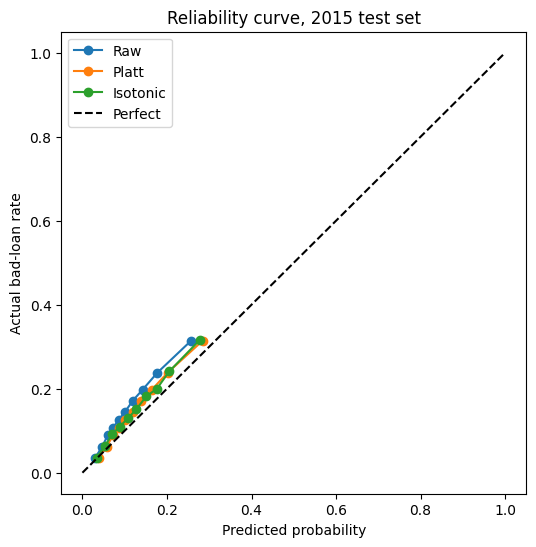

In [10]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.isotonic import IsotonicRegression

feats = safe_num + cat_cols
Xtr, Xte = make_X(feats)
fit_m = (train["issue_d"] < "2014-01-01").values   # 2012-2013: fit the model
cal_m = ~fit_m                                      # 2014: learn the calibration fix

gb2 = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr[fit_m], ytr[fit_m])
p_cal = gb2.predict_proba(Xtr[cal_m])[:, 1]
p_raw = gb2.predict_proba(Xte)[:, 1]

# Platt scaling: logistic regression on the model's log-odds
def to_logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)

platt = LogisticRegression().fit(to_logit(p_cal), ytr[cal_m])
p_platt = platt.predict_proba(to_logit(p_raw))[:, 1]

# Isotonic regression
iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal, ytr[cal_m])
p_iso = iso.predict(p_raw)

print("no-skill Brier (constant guess):", round(yte.mean() * (1 - yte.mean()), 3))
for name, p in [("Raw", p_raw), ("Platt", p_platt), ("Isotonic", p_iso)]:
    print(name, "| Brier:", round(brier_score_loss(yte, p), 4),
          "| PR-AUC:", round(average_precision_score(yte, p), 3),
          "| mean predicted:", round(p.mean(), 3))
print("actual test bad rate:", round(yte.mean(), 3))

plt.figure(figsize=(6, 6))
for name, p in [("Raw", p_raw), ("Platt", p_platt), ("Isotonic", p_iso)]:
    frac_pos, mean_pred = calibration_curve(yte, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)
plt.plot([0, 1], [0, 1], "k--", label="Perfect")
plt.xlabel("Predicted probability"); plt.ylabel("Actual bad-loan rate")
plt.legend(); plt.title("Reliability curve, 2015 test set")
plt.show()

In [11]:
cost_fp = 1000   # rejecting a good loan: lost profit (naira, invented)
cost_fn = 5000   # approving a loan that defaults: loss (naira, invented)

y = yte.values
p = p_platt                       # calibrated probabilities

t_star = cost_fp / (cost_fp + cost_fn)
print("threshold from the costs:", round(t_star, 3))

def total_cost(flag):
    fp = (flag & (y == 0)).sum()
    fn = (~flag & (y == 1)).sum()
    return fp, fn, fp * cost_fp + fn * cost_fn

for name, flag in [("Model at threshold", p >= t_star),
                   ("Approve everyone", np.zeros(len(y), bool)),
                   ("Reject everyone", np.ones(len(y), bool))]:
    fp, fn, c = total_cost(flag)
    print(f"{name:20s} FP={fp:7d}  FN={fn:6d}  total cost={c:,}")

# just to look at the shape of the cost curve, not to pick the threshold
for t in [0.05, 0.10, 0.15, t_star, 0.20, 0.25, 0.30]:
    print(round(t, 3), f"{total_cost(p >= t)[2]:,}")

threshold from the costs: 0.167
Model at threshold   FP=  50260  FN= 24064  total cost=170,580,000
Approve everyone     FP=      0  FN= 42048  total cost=210,240,000
Reject everyone      FP= 240805  FN=     0  total cost=240,805,000
0.05 216,894,000
0.1 174,447,000
0.15 167,708,000
0.167 170,580,000
0.2 178,269,000
0.25 190,863,000
0.3 200,761,000
